In [ ]:
import pandas as pd

df_evaluations=pd.read_json("evaluations_results_pipeline_QS2.json")
print(df_evaluations.shape)
# print("réponses vides;")
# display(df_evaluations[df_evaluations["Score_claude-sonnet-4.6"]==1])

# df_evaluations=(df_evaluations.drop_duplicates(subset=["question"]))


df_evaluations["gemini_ratio_score"]=round(df_evaluations["score_B (RAG)_gemini-3.1-pro-preview"]/df_evaluations["score_A (réf.)_gemini-3.1-pro-preview"], 2)
df_evaluations["gpt_ratio_score"]=round(df_evaluations["score_B (RAG)_gpt-5.2"]/df_evaluations["score_A (réf.)_gpt-5.2"], 2)

df_evaluations["gemini-flash_ratio_score"]=round(df_evaluations["score_B (RAG)_gemini-3-flash-preview"]/df_evaluations["score_A (réf.)_gemini-3-flash-preview"], 2)
df_evaluations["gpt-mini_ratio_score"]=round(df_evaluations["score_B (RAG)_gpt-5-mini"]/df_evaluations["score_A (réf.)_gpt-5-mini"], 2)



display(df_evaluations.drop(columns=[
    "corpus", "question", "date", 'dataset', "difficulte", 'source',
    "reponse_reference", "response",
    "custom_evaluation_text_gpt-5.2", "custom_evaluation_text_gpt-5-mini", "custom_evaluation_text_gemini-3-flash-preview",
    # "custom_evaluation_text_gemini-3.1-pro-preview"
    # 'score_A (réf.)_gemini-3.1-pro-preview', 'score_B (RAG)_gemini-3.1-pro-preview', 
     'score_A (réf.)_gemini-3-flash-preview', 'score_B (RAG)_gemini-3-flash-preview', 
     'score_A (réf.)_gpt-5.2', 'score_B (RAG)_gpt-5.2', 
    'score_A (réf.)_gpt-5-mini', 'score_B (RAG)_gpt-5-mini',    

]))

print("\n===Gap scores group by model et rag type:===\n")
for s in [
    "gemini_ratio_score", "gpt_ratio_score", 
    "gemini-flash_ratio_score", "gpt-mini_ratio_score"
    ]:    
    print(s)
    display(df_evaluations.groupby(["model", 'rag_type'])[s].mean().reset_index())



(108, 23)


,type,rag_type,model,score_A (réf.)_gemini-3.1-pro-preview,score_B (RAG)_gemini-3.1-pro-preview,custom_evaluation_text_gemini-3.1-pro-preview,gemini_ratio_score,gpt_ratio_score,gemini-flash_ratio_score,gpt-mini_ratio_score
0,NEEDLE,graph,DeepSeek-V3.2:novita,8,10,"{'score_A': 8, 'score_B': 10, 'meilleure_repon...",1.25,0.90,1.11,1.12
1,NEEDLE,graph,DeepSeek-V3.2:novita,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...",1.11,0.89,1.00,1.50
2,NEEDLE,graph,DeepSeek-V3.2:novita,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",1.00,1.00,1.11,1.00
3,MULTI_HOP,graph,DeepSeek-V3.2:novita,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",1.00,0.89,1.25,1.29
4,MULTI_HOP,graph,DeepSeek-V3.2:novita,10,6,"{'score_A': 10, 'score_B': 6, 'meilleure_repon...",0.60,0.62,0.70,0.67
...,...,...,...,...,...,...,...,...,...,...
103,FALSE_PREMISE,hybrid_hyde,gpt-oss-120b:cheapest,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...",1.11,1.00,1.00,1.12
104,FALSE_PREMISE,hybrid_hyde,gpt-oss-120b:cheapest,10,8,"{'score_A': 10, 'score_B': 8, 'meilleure_repon...",0.80,0.78,0.80,0.67
105,FALSE_PREMISE,hybrid_hyde,gpt-oss-120b:cheapest,10,8,"{'score_A': 10, 'score_B': 8, 'meilleure_repon...",0.80,0.67,0.70,0.78
106,FALSE_PREMISE,hybrid_hyde,gpt-oss-120b:cheapest,10,7,"{'score_A': 10, 'score_B': 7, 'meilleure_repon...",0.70,0.78,0.80,0.44



===Gap scores group by model et rag type:===

gemini_ratio_score


,model,rag_type,gemini_ratio_score
0,DeepSeek-V3.2:novita,graph,1.057778
1,DeepSeek-V3.2:novita,hybrid,1.110000
2,DeepSeek-V3.2:novita,hybrid_hyde,1.063889
3,gpt-oss-120b:cheapest,graph,0.965000
4,gpt-oss-120b:cheapest,hybrid,0.995000
5,gpt-oss-120b:cheapest,hybrid_hyde,1.026111


gpt_ratio_score


,model,rag_type,gpt_ratio_score
0,DeepSeek-V3.2:novita,graph,0.856111
1,DeepSeek-V3.2:novita,hybrid,1.053333
2,DeepSeek-V3.2:novita,hybrid_hyde,1.050000
3,gpt-oss-120b:cheapest,graph,0.941111
4,gpt-oss-120b:cheapest,hybrid,1.017222
5,gpt-oss-120b:cheapest,hybrid_hyde,1.000000


gemini-flash_ratio_score


,model,rag_type,gemini-flash_ratio_score
0,DeepSeek-V3.2:novita,graph,1.131667
1,DeepSeek-V3.2:novita,hybrid,1.120556
2,DeepSeek-V3.2:novita,hybrid_hyde,1.057222
3,gpt-oss-120b:cheapest,graph,1.036667
4,gpt-oss-120b:cheapest,hybrid,1.030000
5,gpt-oss-120b:cheapest,hybrid_hyde,1.039444


gpt-mini_ratio_score


,model,rag_type,gpt-mini_ratio_score
0,DeepSeek-V3.2:novita,graph,1.206111
1,DeepSeek-V3.2:novita,hybrid,1.308333
2,DeepSeek-V3.2:novita,hybrid_hyde,1.261111
3,gpt-oss-120b:cheapest,graph,1.168333
4,gpt-oss-120b:cheapest,hybrid,1.132222
5,gpt-oss-120b:cheapest,hybrid_hyde,1.087778


In [16]:
# inspecter une question
from IPython.display import Markdown
i=32
question=df_evaluations.loc[i, "question"]
resp=df_evaluations.loc[i, "response"]
ref=df_evaluations.loc[i, "reponse_reference"]
verdict=df_evaluations.loc[i, 'custom_evaluation_text_gemini-3.1-pro-preview']

print("\n=====\nQuestion:", question)

print("\n=====\nRéponse:")
display(Markdown(resp))

print("\n----\nReference:", ref)

display(Markdown(ref))

print(verdict)


=====
Question: Pourquoi Philippe Aghion propose-t-il dans ce podcast de passer à la semaine de 32 heures pour résorber le chômage massif ?

=====
Réponse:


**Raisonnement :**

La question demande pourquoi Philippe Aghion propose dans le podcast de passer à la semaine de 32 heures pour résorber le chômage massif.

Pour répondre à cette question, je dois :
1. Identifier les éléments du corpus distillé concernant la position de Philippe Aghion sur le travail, l'emploi et les réformes.
2. Examiner les fragments récupérés (retrieval) pour trouver des preuves textuelles précisant cette proposition et ses motivations.

**Étape 1 : Analyse du corpus distillé**
Le corpus distillé présente la thèse centrale de Philippe Aghion et les claims associés. Aghion est partisan d'une "social-démocratie de production". Il estime qu'il faut financer le modèle social par l'innovation, la hausse de la productivité (IA) et la flexisécurité. Son objectif principal est d'augmenter le taux d'emploi (des jeunes et des seniors) et de prolonger la durée de la vie active face au défi démographique.
Le corpus distillé n'aborde pas explicitement une proposition de semaine de 32 heures. Les axes conceptuels et les claims se concentrent sur la réforme des retraites, l'insoutenabilité financière, et la relation entre travail et assistance.
Le corpus distillé mentionne une divergence (D1) sur l'origine du blocage français au travail, où Aghion pointe une mauvaise culture managériale, mais cela ne concerne pas directement une réduction du temps de travail pour lutter contre le chômage.

**Étape 2 : Analyse des fragments de documents (retrieval)**
Les fragments récupérés sont **absents**.
Selon les consignes, si le contexte est vide, je dois quitter immédiatement la session avec la réponse 'Contexte absent'.

**Conclusion du raisonnement :**
Les fragments de documents, qui constituent les preuves textuelles permettant d'étayer les affirmations, d'apporter des exemples et de préciser les arguments des interlocuteurs, ne sont pas disponibles. Le corpus distillé ne contient aucune information permettant de répondre à la question spécifique sur la proposition de la semaine de 32 heures par Philippe Aghion. En l'absence de contexte textuel pertinent, je ne peux construire une réponse basée sur les documents fournis.

**Réponse :**
Contexte absent

**Sources :**
Aucune.


----
Reference: Le contexte fourni ne permet pas de répondre à cette question car Philippe Aghion n'y propose à aucun moment de passer à la semaine de 32 heures ; il affirme au contraire qu'il va falloir travailler davantage.


Le contexte fourni ne permet pas de répondre à cette question car Philippe Aghion n'y propose à aucun moment de passer à la semaine de 32 heures ; il affirme au contraire qu'il va falloir travailler davantage.

{'score_A': 10, 'score_B': 7, 'meilleure_reponse': 'A', 'evaluation': {'verdict': "La réponse A identifie et corrige explicitement la fausse prémisse, tandis que la réponse B l'identifie dans son raisonnement mais finit par un refus générique dû à l'absence de fragments.", 'points_cles': {'communs': ['Refus de répondre positivement à la question (ne valide pas la prémisse).', "Absence d'hallucinations extérieures au corpus."], 'specifiques_A': ["Correction explicite de la fausse prémisse en précisant la véritable position d'Aghion (travailler davantage)."], 'specifiques_B': ['Exposition détaillée du raisonnement interne et des consignes.', "Conclusion sur 'Contexte absent' en raison du manque de fragments."]}, 'analyse_A': {'qualite': "Excellente gestion de la fausse prémisse : A l'identifie et la déconstruit immédiatement en remettant la véritable position discutée dans le corpus.", 'limites': 'Aucune limite notable.'}, 'analyse_B': {'qualite': "Bonne analyse dans le raisonnement : B 

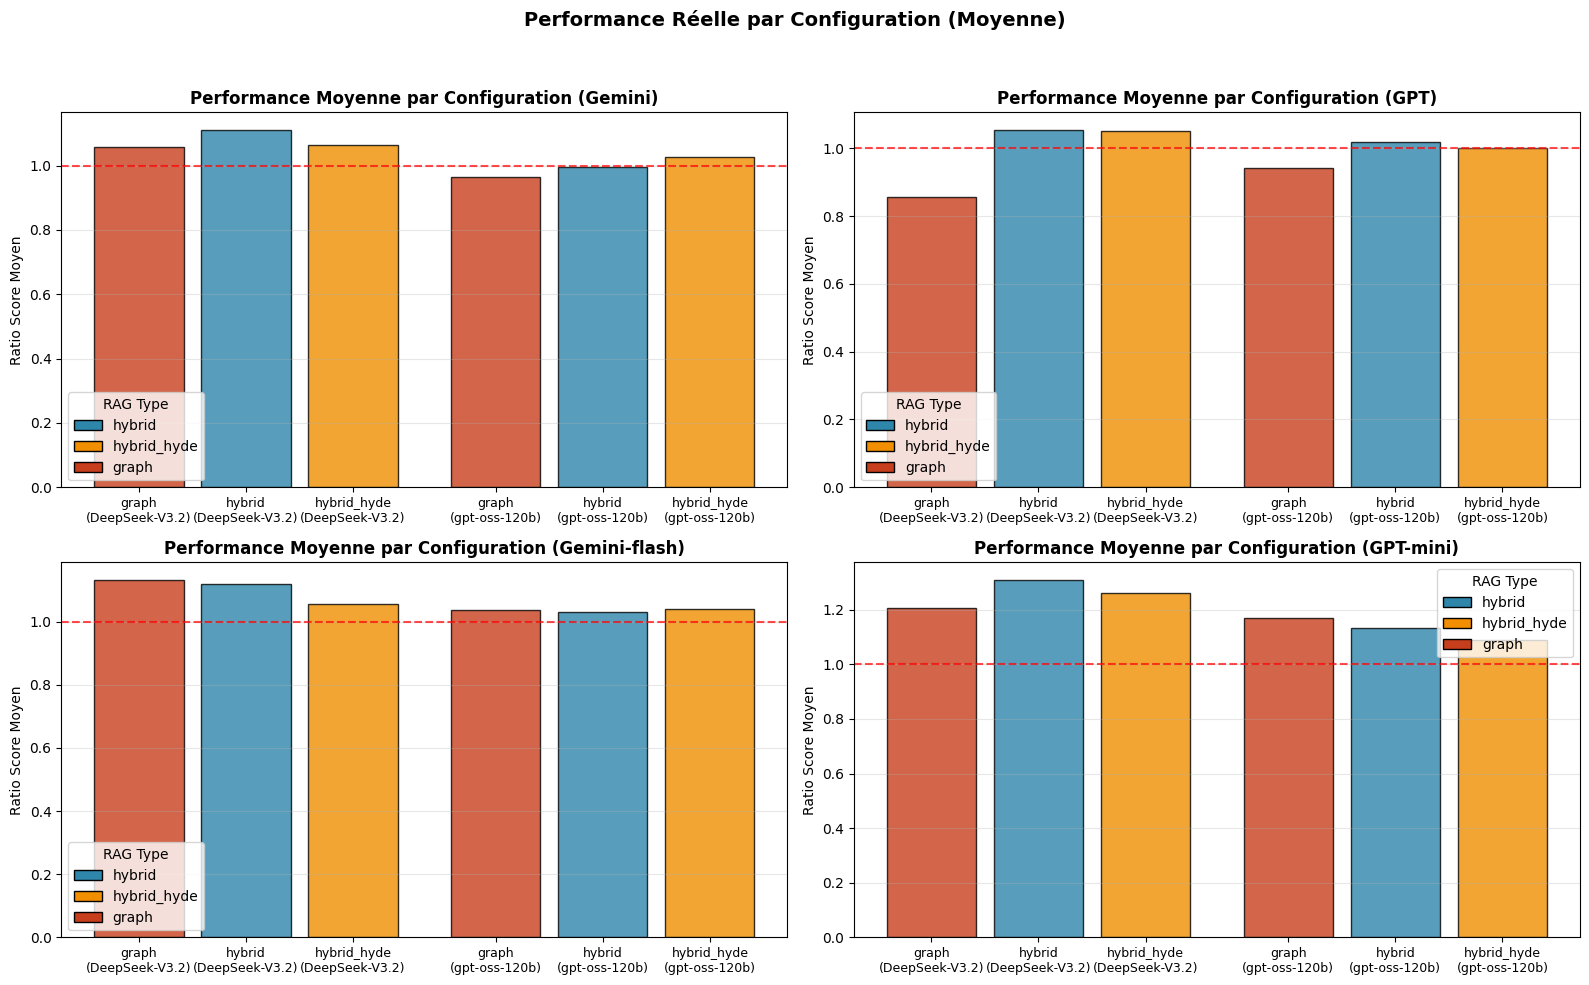

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_viz = df_evaluations.copy()
df_viz['model_short'] = df_viz['model'].str.split(':').str[0]

# Calcul des moyennes
agg_gemini = df_viz.groupby(['model_short', 'rag_type'])['gemini_ratio_score'].mean().reset_index()
agg_gemini_flash = df_viz.groupby(['model_short', 'rag_type'])['gemini-flash_ratio_score'].mean().reset_index()
agg_gpt = df_viz.groupby(['model_short', 'rag_type'])['gpt_ratio_score'].mean().reset_index()
agg_gpt_mini = df_viz.groupby(['model_short', 'rag_type'])['gpt-mini_ratio_score'].mean().reset_index()


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

models = df_viz['model_short'].unique()
colors = {'hybrid': '#2E86AB', 'hybrid_hyde': '#F18F01', 'graph': '#C73E1D'}

for ax, data, title in [
    (axes[0], agg_gemini, 'Gemini'), 
    (axes[1], agg_gpt, 'GPT'),
    (axes[2], agg_gemini_flash, 'Gemini-flash'), 
    (axes[3], agg_gpt_mini, 'GPT-mini')                                                 
]:
    
    x_pos = 0
    width = 0.25
    positions = []
    labels = []
    
    for model in models:
        subset = data[data['model_short'] == model]
        for _, row in subset.iterrows():
            positions.append(x_pos)
            labels.append(f"{row['rag_type']}\n({row['model_short']})")
            ax.bar(x_pos, row.iloc[2], width, 
                   color=colors[row['rag_type']], 
                   edgecolor='black', alpha=0.8)
            x_pos += width + 0.05
        
        x_pos += 0.1
    
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('Ratio Score Moyen', fontsize=10)
    ax.set_title(f'Performance Moyenne par Configuration ({title})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[r], edgecolor='black', label=r) 
                       for r in ['hybrid', 'hybrid_hyde', 'graph']]
    ax.legend(handles=legend_elements, title='RAG Type')

plt.suptitle('Performance Réelle par Configuration (Moyenne)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

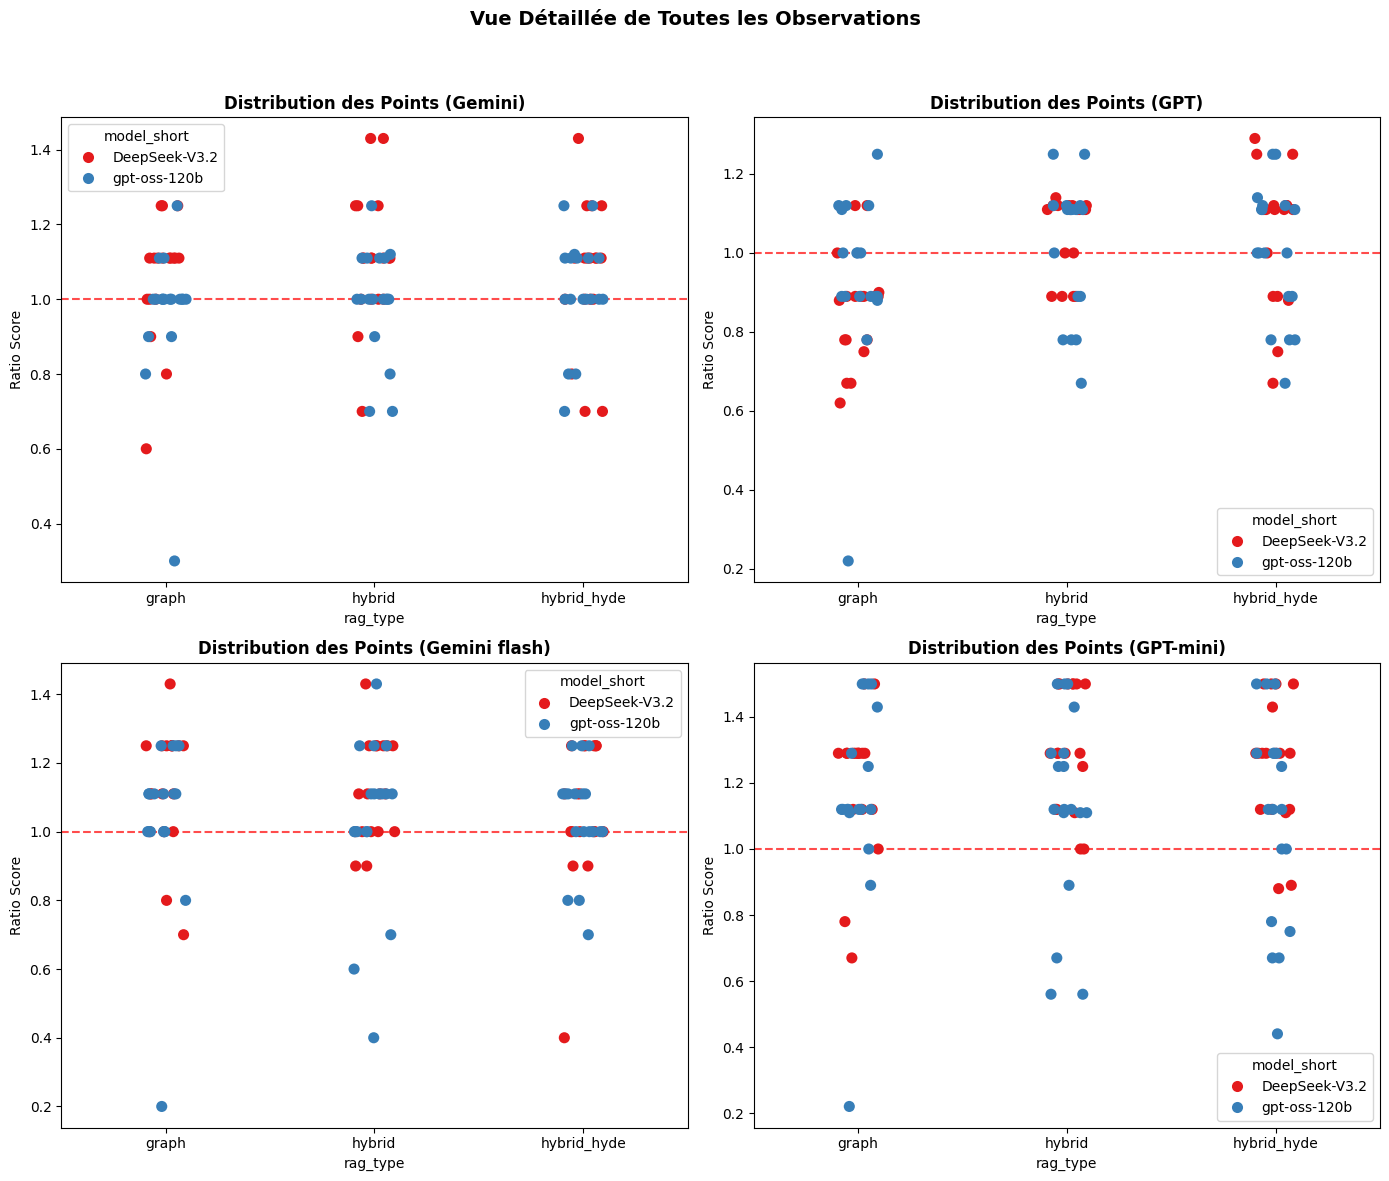

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # Correction : convertir en tableau 1D

# Stripplot pour voir tous les points individuels
sns.stripplot(data=df_viz, x='rag_type', y='gemini_ratio_score', 
              hue='model_short', ax=axes[0], size=8, palette='Set1')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Distribution des Points (Gemini)', fontweight='bold')
axes[0].set_ylabel('Ratio Score')

sns.stripplot(data=df_viz, x='rag_type', y='gpt_ratio_score', 
              hue='model_short', ax=axes[1], size=8, palette='Set1')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Distribution des Points (GPT)', fontweight='bold')
axes[1].set_ylabel('Ratio Score')

# Stripplot pour voir tous les points individuels
sns.stripplot(data=df_viz, x='rag_type', y='gemini-flash_ratio_score', 
              hue='model_short', ax=axes[2], size=8, palette='Set1')
axes[2].axhline(1.0, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('Distribution des Points (Gemini flash)', fontweight='bold')
axes[2].set_ylabel('Ratio Score')

# Ajout du 4ème graphique manquant (GPT-mini)
sns.stripplot(data=df_viz, x='rag_type', y='gpt-mini_ratio_score', 
              hue='model_short', ax=axes[3], size=8, palette='Set1')
axes[3].axhline(1.0, color='red', linestyle='--', alpha=0.7)
axes[3].set_title('Distribution des Points (GPT-mini)', fontweight='bold')
axes[3].set_ylabel('Ratio Score')

plt.suptitle('Vue Détaillée de Toutes les Observations', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [2]:
df_tokens_usage_graph=pd.read_json("logs/tokens_usage_graph.json")
print(df_tokens_usage_graph.shape)
df_tokens_usage_graph

(65, 11)


,hash_query,rag_type,query,date,input_tokens,completion_tokens,reasoning_tokens,input_price,completion_price,reasoning_price,model
0,4c876d3f4b72bf45d3c57b0bd06f7050,pathrag,\n Peux tu me faire une synthèse de...,2026-03-07 15:00:40.316437,515,73,0,0.00014,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita
1,d98228ef4922f022fd3993e5ef8e10a3,pathrag,"Pour chaque intervenant, peux-tu résumer son ...",2026-03-07 15:25:39.868283,462,64,0,0.00012,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita
2,d98228ef4922f022fd3993e5ef8e10a3,pathrag,"Pour chaque intervenant, peux-tu résumer son ...",2026-03-07 15:26:25.950428,22881,1259,0,0.00618,0.00050,0,deepseek-ai/DeepSeek-V3.2:novita
3,efa6970869eebd54536e6367c0132332,pathrag,"\n Dans ce qui est dit, qu’...",2026-03-07 15:27:14.411920,492,70,0,0.00013,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita
4,efa6970869eebd54536e6367c0132332,pathrag,"\n Dans ce qui est dit, qu’...",2026-03-07 15:28:08.884586,22678,1626,0,0.00612,0.00065,0,deepseek-ai/DeepSeek-V3.2:novita
...,...,...,...,...,...,...,...,...,...,...,...
60,c7504e683c6f11dbf714f2699b7f907c,hypergraph,"Pour chaque intervenant, peux-tu résumer son ...",2026-03-07 23:32:44.335419,19107,605,0,0.01146,0.00151,0,moonshotai/Kimi-K2-Instruct-0905:novita
61,e44e8e2e43d3cae0f9e26bad3b642649,hypergraph,"\n Dans ce qui est dit, qu’...",2026-03-07 23:34:23.912265,3954,440,0,0.00237,0.00110,0,moonshotai/Kimi-K2-Instruct-0905:novita
62,e44e8e2e43d3cae0f9e26bad3b642649,hypergraph,"\n Dans ce qui est dit, qu’...",2026-03-07 23:35:45.559739,20395,1113,0,0.01224,0.00278,0,moonshotai/Kimi-K2-Instruct-0905:novita
63,1bdaf69794f15ff398af796907685bdc,hypergraph,\n Quels sont les arguments...,2026-03-07 23:37:09.847453,3942,290,0,0.00237,0.00072,0,moonshotai/Kimi-K2-Instruct-0905:novita


In [3]:
df_tokens_usage_hybrid=pd.read_json("logs/tokens_usage_hybrid.json")
print(df_tokens_usage_hybrid.shape)
df_tokens_usage_hybrid

(34, 3)


,graph,hybrid,hybrid_hyde
0,{},{'10e27b16b820d8ea5076c7ccd32dd8e9': {'query':...,{}
1,{},{'5fdbc9b1e0d52ffac452e81f439381f4': {'query':...,{}
2,{},{'87aa24f88e680293a7264af6a67390bf': {'query':...,{}
3,{},{'87aa24f88e680293a7264af6a67390bf': {'query':...,{}
4,{},{'87aa24f88e680293a7264af6a67390bf': {'query':...,{'10e27b16b820d8ea5076c7ccd32dd8e9': {'query':...
5,{},{'87aa24f88e680293a7264af6a67390bf': {'query':...,{'10e27b16b820d8ea5076c7ccd32dd8e9': {'query':...
6,{},{},{'87aa24f88e680293a7264af6a67390bf': {'query':...
7,{},{},{'87aa24f88e680293a7264af6a67390bf': {'query':...
8,{},{'10e27b16b820d8ea5076c7ccd32dd8e9': {'query':...,{}
9,{},{'10e27b16b820d8ea5076c7ccd32dd8e9': {'query':...,{'10e27b16b820d8ea5076c7ccd32dd8e9': {'query':...


In [4]:
import pandas as pd

# 1. Mapping des types RAG
rag_type_mapping = {
    'graph': 'pathrag', 
    'hybrid': 'hybrid', 
    'hybrid_hyde': 'hybrid_hyde'
}

records = []
columns_to_process = ['graph', 'hybrid', 'hybrid_hyde']

for col in columns_to_process:
    # Vérifie si la colonne existe dans le dataframe
    if col not in df_tokens_usage_hybrid.columns:
        continue
        
    for idx, cell_data in df_tokens_usage_hybrid[col].items():
        
        if isinstance(cell_data, dict) and cell_data:
            
            for query_hash, details in cell_data.items():
                
                # Extraction sécurisée des sous-dictionnaires de prix
                prices_final = details.get('final_response_price', {})
                prices_reranker = details.get('reranker_price', {})
                prices_hyde = details.get('hyde_tokens_price', {})
                
                # Gestion des tokens (certains JSON ont '_tokens', d'autres non)
                # On essaie la version longue, sinon la version courte
                input_tokens = details.get('final_response_input_tokens') or details.get('final_response_input')
                output_tokens = details.get('final_response_output_tokens') or details.get('final_response_output')
                reasoning_tokens = details.get('final_reasoning_output_tokens') or details.get('final_reasoning_output')
                
                row = {
                    'hash_query': query_hash,
                    'rag_type': rag_type_mapping.get(col, col),
                    'query': details.get('query', '').strip(),
                    'date': details.get('date'),
                    
                    # Tokens Génération Finale
                    'input_tokens': input_tokens,
                    'completion_tokens': output_tokens,
                    'reasoning_tokens': reasoning_tokens,
                    
                    # Prix Génération Finale
                    'input_price_final': prices_final.get('input_price'),
                    'completion_price_final': prices_final.get('completion_price'),
                    'reasoning_price_final': prices_final.get('reasoning_price'),
                    
                    # Prix Reranker (si présent)
                    'input_price_reranker': prices_reranker.get('input_price'),
                    'completion_price_reranker': prices_reranker.get('completion_price'),
                    
                    # Prix Hyde (si présent)
                    'input_price_hyde': prices_hyde.get('input_price'),
                    'completion_price_hyde': prices_hyde.get('completion_price'),
                    
                    'model': details.get('model_generation')
                }
                records.append(row)

# 4. Création du DataFrame
df_flat = pd.DataFrame(records)

# ... (Votre code de création du DataFrame et conversion numérique) ...

# On convertit uniquement les colonnes qui existent vraiment dans le dataframe
existing_numeric_cols = [c for c in numeric_cols if c in df_flat.columns]
df_flat[existing_numeric_cols] = df_flat[existing_numeric_cols].apply(pd.to_numeric, errors='ignore')

# ==============================================================================
# ÉTAPE 1 : CRÉATION DES TOTAUX (Si absents)
# ==============================================================================
# On s'assure que les colonnes de base existent avant de calculer les totaux
base_price_cols = {
    'total_price_final': ['input_price_final', 'completion_price_final', 'reasoning_price_final'],
    'total_price_hyde': ['input_price_hyde', 'completion_price_hyde'],
    'total_price_reranker': ['input_price_reranker', 'completion_price_reranker']
}

for total_col, sub_cols in base_price_cols.items():
    if total_col not in df_flat.columns:
        # On prend uniquement les sous-colonnes qui existent vraiment
        valid_sub_cols = [c for c in sub_cols if c in df_flat.columns]
        if valid_sub_cols:
            df_flat[total_col] = df_flat[valid_sub_cols].fillna(0).sum(axis=1)
        else:
            df_flat[total_col] = 0.0

# ==============================================================================
# ÉTAPE 2 : HACK - Propagation des données Reranker par hash_query
# ==============================================================================
reranker_cols = ['input_price_reranker', 'completion_price_reranker']

# On vérifie que les colonnes source existent
if all(col in df_flat.columns for col in reranker_cols):
    
    # 1. Récupération de la première valeur non-NaN par hash_query
    reranker_lookup = df_flat.groupby('hash_query')[reranker_cols].first()
    
    # 2. Remplissage des trous (NaN) pour les lignes hybrid_hyde
    for col in reranker_cols:
        df_flat[col] = df_flat[col].fillna(df_flat['hash_query'].map(reranker_lookup[col]))
    
    # 3. Recalcul des totaux avec les nouvelles valeurs remplies
    df_flat['total_price_reranker'] = df_flat['input_price_reranker'].fillna(0) + df_flat['completion_price_reranker'].fillna(0)
    
    # Vérification de sécurité pour total_price_final avant le calcul final
    if 'total_price_final' not in df_flat.columns:
        df_flat['total_price_final'] = 0.0
    if 'total_price_hyde' not in df_flat.columns:
        df_flat['total_price_hyde'] = 0.0
        
    df_flat['total_price'] = (
        df_flat['total_price_final'] + 
        df_flat['total_price_reranker'] + 
        df_flat['total_price_hyde']
    )

# ==============================================================================
# ÉTAPE 3 : NETTOYAGE DES DOUBLONS
# ==============================================================================
df_flat = df_flat.drop_duplicates().reset_index(drop=True)

# Affichage de vérification
(df_flat)

NameError: name 'numeric_cols' is not defined

In [30]:

# Assume openai>=1.0.0
from openai import OpenAI
import os
import dotenv
dotenv.load_dotenv("/home/chougar/Documents/GitHub/.env")

# Create an OpenAI client with your deepinfra token and endpoint
openai = OpenAI(
    api_key=os.getenv("DEEPINFRA_API_KEY"),
    base_url="https://api.deepinfra.com/v1/openai",
)


chat_completion = openai.chat.completions.create(
    model="mistralai/Mistral-Small-3.2-24B-Instruct-2506",
    messages=[
        {"role": "system", "content": "you are a kind pirate"},
        {"role": "user", "content": "Hello"}],
        temperature=0,
        extra_headers={
            "HTTP-Referer": "audio-hybrid-rag-reranker",
            "X-Title": "audio-hybrid-rag-reranker",
        },
        extra_body={
            "user": f"audio-hybrid-rag-reranker-",
            # "reasoning": {"enabled": False}
        },                            
    )


print(chat_completion.choices[0].message.content)
print(chat_completion.usage.prompt_tokens, chat_completion.usage.completion_tokens)

# Hello! It's nice to meet you. Is there something I can help you with, or would you like to chat?
# 11 25


Arr matey! Welcome aboard me humble digital ship! I be here to help ye with any questions or tasks ye might have. Be it navigatin' the treacherous seas of knowledge or just lookin' for a friendly chat, I'm at yer service. What can I do for ye today? *adjusts eyepatch and grins*
11 74
